# Mostly Noise \U0001F9F1
### Your risk model has 1,275 numbers in it. Perhaps five of them are real.

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

Every optimiser, every risk report and every "diversified" portfolio rests on a correlation
matrix. Nobody prints an error bar on one. There is a sixty-year-old piece of mathematics that
says exactly how much of it can possibly be real, and it needs no data at all — only how many
assets you have and how many days you measured them over.

> \U0001F4D3 **This is the plain-language layer.** The eigenvalue spectrum, the known-factor
> control and the estimator race are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| How much of the matrix is measurable? | A handful of numbers out of a thousand. |
| Can you know that in advance? | Yes — from N and T alone. |
| Does it look stable? | Only because stocks move together. |
| Does cleaning help? | Yes, mostly by stopping the optimiser fooling itself. |

## 1 · The problem, in one calculation

In [2]:
from corrnoise import data, strategy as st

px = data.load_prices()
cols = [c for c in data.NAMES if c in px.columns and px[c].dropna().shape[0] > 2500]
R = px[cols].pct_change().dropna()
print(f"as-of {data.AS_OF} | {len(cols)} names, {len(R):,} common sessions from "
      f"{R.index[0].date()}")
p = st.parameters_vs_observations(len(cols), 252)
print(f"a {len(cols)}x{len(cols)} covariance matrix = {p['n_parameters']:,} parameters")
print(f"a 252-day window = {p['n_observations']:,} observations "
      f"({p['observations_per_parameter']:.1f} per parameter)")

as-of 2026-06-30 | 50 names, 4,146 common sessions from 2010-01-05
a 50x50 covariance matrix = 1,275 parameters
a 252-day window = 12,600 observations (9.9 per parameter)


In [3]:
b = st.marchenko_pastur_bounds(len(cols), 252)
print(f"q = number of assets / number of days = {b['q']:.4f}")
print()
print("Marchenko & Pastur (1967) proved that if the assets were COMPLETELY UNRELATED,")
print("the eigenvalues of the measured correlation matrix would still scatter across")
print(f"    [{b['lambda_minus']:.3f}, {b['lambda_plus']:.3f}]")
print()
print("Anything landing in that range tells you nothing. And note: computing it did")
print("not require a single price. Only N and T.")

q = number of assets / number of days = 0.1984

Marchenko & Pastur (1967) proved that if the assets were COMPLETELY UNRELATED,
the eigenvalues of the measured correlation matrix would still scatter across
    [0.308, 2.089]

Anything landing in that range tells you nothing. And note: computing it did
not require a single price. Only N and T.


## 2 · The picture

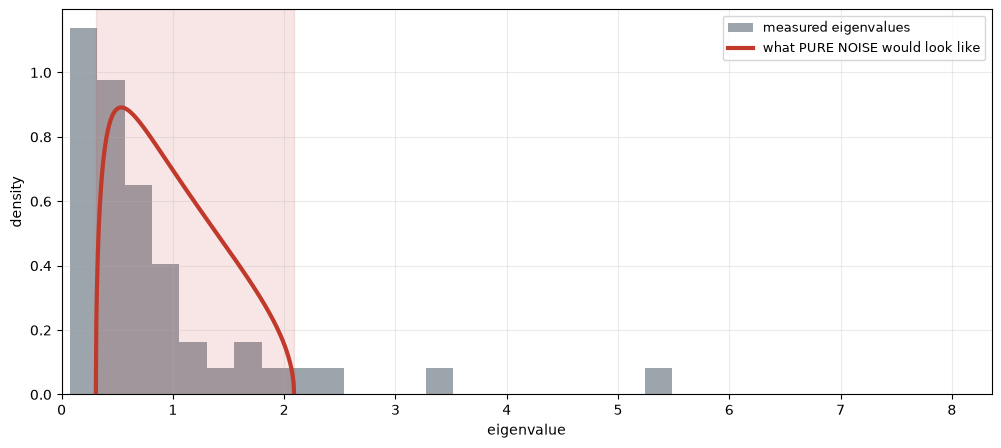

5 eigenvalues escape the noise band. 31 do not.
the largest is 9.9 -- that is 'the stock market', 20% of all variance


In [4]:
s = st.spectrum_analysis(R.iloc[-252:])
ev = s["eigenvalues"]
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(ev, bins=40, color="#8b949e", density=True, alpha=0.85,
        label="measured eigenvalues")
xs = np.linspace(s["lambda_minus"], s["lambda_plus"], 400)
ax.plot(xs, st.mp_density(xs, s["q"]), lw=3, color="#c0392b",
        label="what PURE NOISE would look like")
ax.axvspan(s["lambda_minus"], s["lambda_plus"], alpha=0.12, color="#c0392b")
ax.set_xlim(0, min(max(ev) * 1.05, s["lambda_plus"] * 4))
ax.set_xlabel("eigenvalue"); ax.set_ylabel("density"); ax.legend(fontsize=9)
plt.show()
print(f"{s['n_above']} eigenvalues escape the noise band. {s['n_inside']} do not.")
print(f"the largest is {s['largest']:.1f} -- that is 'the stock market', "
      f"{s['largest_share']:.0%} of all variance")

The red curve is what you would see if these fifty companies had **nothing whatsoever** to do
with each other. Almost the whole histogram sits under it.

## 3 · Checking the tool before believing it

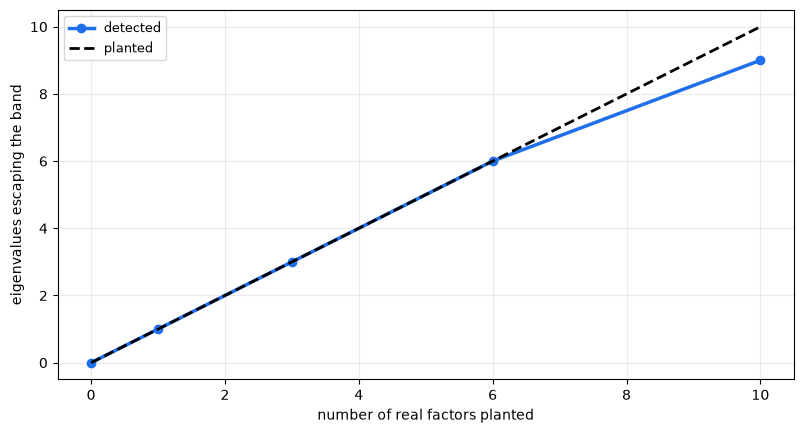

                 eigenvalues above the band  share inside
factors planted                                          
0                                         0        1.0000
1                                         1        0.7600
3                                         3        0.4800
6                                         6        0.1200
10                                        9        0.0200


In [5]:
rows = []
for k in (0, 1, 3, 6, 10):
    sim = st.synthetic_returns(len(cols), 252, n_factors=k, factor_strength=1.0)
    sp = st.spectrum_analysis(sim)
    rows.append({"factors planted": k, "eigenvalues above the band": sp["n_above"],
                 "share inside": sp["share_inside"]})
d = pd.DataFrame(rows).set_index("factors planted")
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(d.index, d["eigenvalues above the band"], "o-", lw=2.5, color="#1f6feb",
        label="detected")
ax.plot(d.index, d.index, "k--", lw=2, label="planted")
ax.set_xlabel("number of real factors planted")
ax.set_ylabel("eigenvalues escaping the band"); ax.legend(fontsize=9)
plt.show()
print(d.round(3).to_string())

On simulated data where we *know* the answer, the method finds the right number of real factors
— and finds nothing when there is nothing. Only then is it worth pointing at a market.

## 4 · The "but correlations are stable" objection

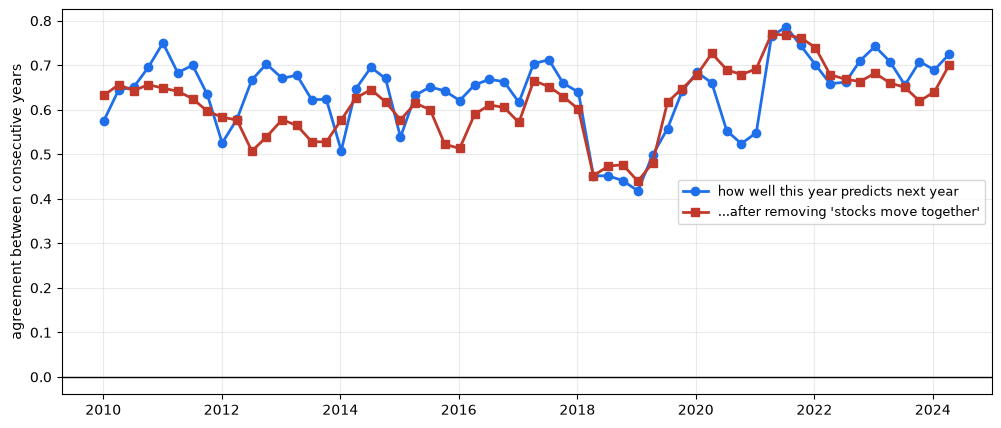

raw agreement:                    0.638
agreement after removing market:  0.617


In [6]:
per = st.matrix_persistence(R, window=252, step=63)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(per["start"], per["pairwise_corr"], "o-", lw=2, color="#1f6feb",
        label="how well this year predicts next year")
ax.plot(per["start"], per["residual_corr"], "s-", lw=2, color="#c0392b",
        label="...after removing 'stocks move together'")
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("agreement between consecutive years"); ax.legend(fontsize=9)
plt.show()
ps = st.persistence_summary(per)
print(f"raw agreement:                    {ps['pairwise']:.3f}")
print(f"agreement after removing market:  {ps['residual']:.3f}")

> \U0001F52C **For the quants.** The blue line is the statistic people cite for "correlations
> are stable". Nearly all of it is the single fact that equities co-move. The red line is what
> is left of the matrix's *structure*, and it is much less encouraging.

## 5 · Does any of this matter for a portfolio?

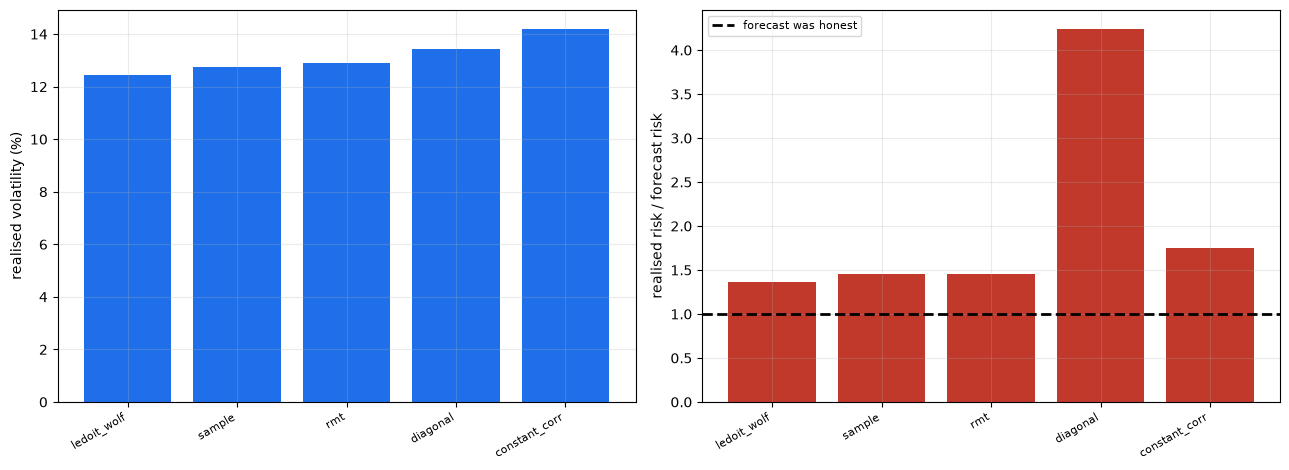

               realised_vol  forecast_vol  calibration  calibration_sd  gross_leverage  effective_n  n_periods
method                                                                                                        
ledoit_wolf          0.1245        0.0942       1.3584          0.8320          2.1407       5.5796         61
sample               0.1274        0.0918       1.4566          0.8911          2.9622       3.6511         61
rmt                  0.1288        0.0925       1.4516          0.9247          2.1998       5.2228         61
diagonal             0.1345        0.0331       4.2439          2.8190          1.0000      39.0083         61
constant_corr        0.1421        0.0819       1.7483          0.7413          2.1157       5.3758         61


In [7]:
summ = st.race_summary(st.portfolio_horse_race(R, 252, 63))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].bar(summ.index, summ["realised_vol"] * 100, color="#1f6feb")
axes[0].set_ylabel("realised volatility (%)")
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right", fontsize=8)
axes[1].bar(summ.index, summ["calibration"],
            color=["#c0392b" if abs(c - 1) > 0.15 else "#2ea44f"
                   for c in summ["calibration"]])
axes[1].axhline(1.0, color="k", ls="--", lw=2, label="forecast was honest")
axes[1].set_ylabel("realised risk / forecast risk"); axes[1].legend(fontsize=8)
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right", fontsize=8)
plt.tight_layout(); plt.show()
print(summ.round(4).to_string())

The right-hand chart is the important one. Fed the raw matrix, the optimiser builds a portfolio
and tells you its risk — and is wrong by a large factor, always in the same direction. It picks
exactly the positions where the noise happened to look reassuring.

Note the **diagonal** bar: that is throwing away every correlation and using only individual
volatilities. It is a much harder benchmark than it sounds.

## 6 · The verdict

**Signal: Confirmed.** Most of it, and the amount is calculable before any data is collected. Estimating a 50×50 covariance matrix means fitting **1,275 parameters** from 252 observations per asset; at q = N/T = 0.198, Marchenko-Pastur puts the pure-noise eigenvalue band at [0.308, 2.089]. On the real matrix, **31 of 50 eigenvalues fall inside it** — 62% of the spectrum, carrying 48% of the total variance and indistinguishable from a matrix of random numbers. Only **5 escape upward**, and the largest of those is simply the market: it alone accounts for 20% of the variance. A further 14 fall *below* the band, which is not signal either — those are the near-degenerate directions that make the matrix ill-conditioned, and an optimiser is drawn to precisely them because a tiny variance estimate looks like a free lunch. Lengthening the estimation window does not fix this: at 2520 days the informative count is still only 4. More data narrows the band; it does not manufacture factors that were never there. The synthetic control confirms the machinery rather than the story — with **independent** assets by construction, 99% of the spectrum lands inside the band as it must, and planting 3 factors puts 3.0 eigenvalues above it. Persistence tells the same story from another direction: consecutive windows' pairwise correlations agree at 0.64, which sounds reassuring until the market factor is removed, after which the residual agreement is **0.62**. Almost all the apparent stability is the single fact that stocks move together.

**Tradability: Useful.** Cleaning helps, mostly by stopping the optimiser lying to itself. Fed the raw sample matrix, a minimum-variance portfolio forecast 9.2% volatility and realised 12.7% — a calibration ratio of **1.46**, because the optimiser selects precisely the directions where noise made the variance look smallest. ledoit_wolf brought that to 1.36 while realising 12.5%. The honest benchmark is the diagonal matrix — throwing every correlation away — which realised 13.4% at a calibration of 4.24; the cleaned estimators earn their place against it. Ledoit-Wolf shrank toward its target with an average intensity of **0.37**, i.e. the estimator itself concluded that roughly that fraction of the sample matrix was not worth keeping. Two practical readings. First, the estimation window is a real choice with a computable cost: at 63 days the band swallows 90% of the spectrum against 14% at 2520. Second, a long-only constraint removes much of the damage on its own — gross leverage falls from 3.0× to 1.0× — so a good deal of what cleaning buys is available for free to anyone who cannot short anyway.

## 7 · Going further \U0001F6AA

- **Compute q before choosing a lookback.** If N/T is not small, no amount of care with the
  estimator recovers what was never measured. That calculation costs nothing and is skipped
  almost universally.
- **Shrink, or constrain, or both.** Ledoit-Wolf shrinkage is a one-line change to most
  pipelines. A long-only constraint achieves much of the same thing for free — which is
  Jagannathan and Ma's (2003) result, and section 8 of the results reproduces it.
- **Be suspicious of a risk number without a calibration record.** "This portfolio has 6%
  volatility" is a forecast. Whether the last twenty such forecasts came true is the only thing
  that makes it worth hearing.
- **The market factor is the honest part.** One eigenvalue is real, large and stable. Most of
  the rest of the matrix is decoration, and a model built on a handful of factors plus a
  diagonal is not a crude approximation — it is close to all the information there is.